 Install Dependencies

In [7]:
# Install required libraries
import sys
!{sys.executable} -m pip install kaggle scikit-learn pandas numpy matplotlib seaborn wordcloud gradio joblib --quiet
print(" All packages installed")


 All packages installed


 Imports & Configuration

In [8]:
import os, re, warnings, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_curve, auc,
)
import joblib

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Plot theme ────────────────────────────────────────────────────────────────
PALETTE  = {"Fake": "#E74C3C", "Real": "#2ECC71"}
BG       = "#0F1117"
GRID_CLR = "#2A2D3E"
TEXT_CLR = "#EAEAEA"

def style_ax(ax, title="", xlabel="", ylabel=""):
    ax.set_facecolor(BG)
    ax.tick_params(colors=TEXT_CLR, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_CLR)
    ax.xaxis.label.set_color(TEXT_CLR)
    ax.yaxis.label.set_color(TEXT_CLR)
    ax.title.set_color(TEXT_CLR)
    ax.grid(axis="y", color=GRID_CLR, linewidth=0.5, linestyle="--")
    if title:  ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9)

print(" Imports complete")


 Imports complete


Kaggle Credentials & Dataset Download




In [9]:
import os, json, subprocess, shutil


KAGGLE_USERNAME = "harshitrajtaneja"
KAGGLE_KEY      = "d739911a7addd9b4a83f9a145b009b21"


DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

# Write credentials to ~/.kaggle/kaggle.json
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}
creds_path = os.path.join(kaggle_dir, "kaggle.json")
with open(creds_path, "w") as f:
    json.dump(creds, f)
os.chmod(creds_path, 0o600)   # required by Kaggle API
print(f" Credentials written to {creds_path}")

# Download dataset
print("\nDownloading dataset from Kaggle …")
result = subprocess.run(
    ["kaggle", "datasets", "download",
     "-d", "emineyetm/fake-news-detection-datasets",
     "--unzip", "-p", DATA_DIR],
    capture_output=True, text=True
)

if result.returncode == 0:
    print(" Dataset downloaded successfully!")
    print(f"  Files in {DATA_DIR}/:", os.listdir(DATA_DIR))
else:
    print(" Download failed. Output:")
    print(result.stdout)
    print(result.stderr)
    print("  Check your KAGGLE_USERNAME and KAGGLE_KEY above.")


 Credentials written to /root/.kaggle/kaggle.json

 Dataset downloaded successfully!
  Files in ./data/: ['News _dataset']


In [12]:
import pandas as pd

data_subdir = os.path.join(DATA_DIR, "News _dataset")
fake_path = os.path.join(data_subdir, "Fake.csv")
true_path = os.path.join(data_subdir, "True.csv")

if os.path.exists(fake_path) and os.path.exists(true_path):
    fake = pd.read_csv(fake_path); fake["label"] = 0   # 0 = Fake
    real = pd.read_csv(true_path); real["label"] = 1   # 1 = Real
    df = pd.concat([fake, real], ignore_index=True)
    df["text"] = (df.get("title", "").fillna("") + " " +
                  df.get("text",  "").fillna(""))
    df = df[["text", "label"]].dropna()
    print(f"✔ Dataset loaded successfully!")
    print(f"  Total articles : {len(df):,}")
    print(f"  Fake           : {(df.label==0).sum():,}")
    print(f"  Real           : {(df.label==1).sum():,}")
else:
    raise FileNotFoundError(
        "Fake.csv / True.csv not found in ./data/News _dataset/"
        "Please run the cell above with valid Kaggle credentials."
    )

df["word_count"] = df["text"].str.split().str.len()
df["label_name"] = df["label"].map({0: "Fake", 1: "Real"})
df.head()


✔ Dataset loaded successfully!
  Total articles : 44,898
  Fake           : 23,481
  Real           : 21,417


,text,label,word_count,label_name
0,Donald Trump Sends Out Embarrassing New Year’...,0,507,Fake
1,Drunk Bragging Trump Staffer Started Russian ...,0,313,Fake
2,Sheriff David Clarke Becomes An Internet Joke...,0,595,Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,0,458,Fake
4,Pope Francis Just Called Out Donald Trump Dur...,0,431,Fake


 Exploratory Data Analysis (EDA)

 3.1 Class Distribution

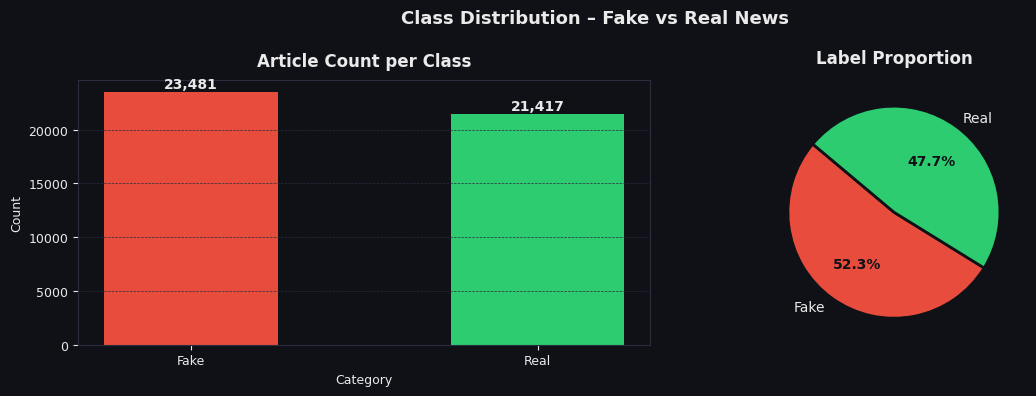

In [13]:
counts = df["label_name"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)
fig.suptitle("Class Distribution – Fake vs Real News",
             color=TEXT_CLR, fontsize=13, fontweight="bold")

# Bar chart
ax = axes[0]
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[l] for l in counts.index],
              edgecolor="none", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}", ha="center", va="bottom",
            color=TEXT_CLR, fontsize=10, fontweight="bold")
style_ax(ax, "Article Count per Class", "Category", "Count")

# Pie chart
ax = axes[1]
ax.set_facecolor(BG)
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index,
    colors=[PALETTE[l] for l in counts.index],
    autopct="%1.1f%%", startangle=140,
    wedgeprops=dict(edgecolor=BG, linewidth=2))
for t in texts:      t.set_color(TEXT_CLR)
for a in autotexts:  a.set_color(BG); a.set_fontweight("bold")
ax.set_title("Label Proportion", color=TEXT_CLR,
             fontsize=12, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()


 3.2 Article Length Distribution





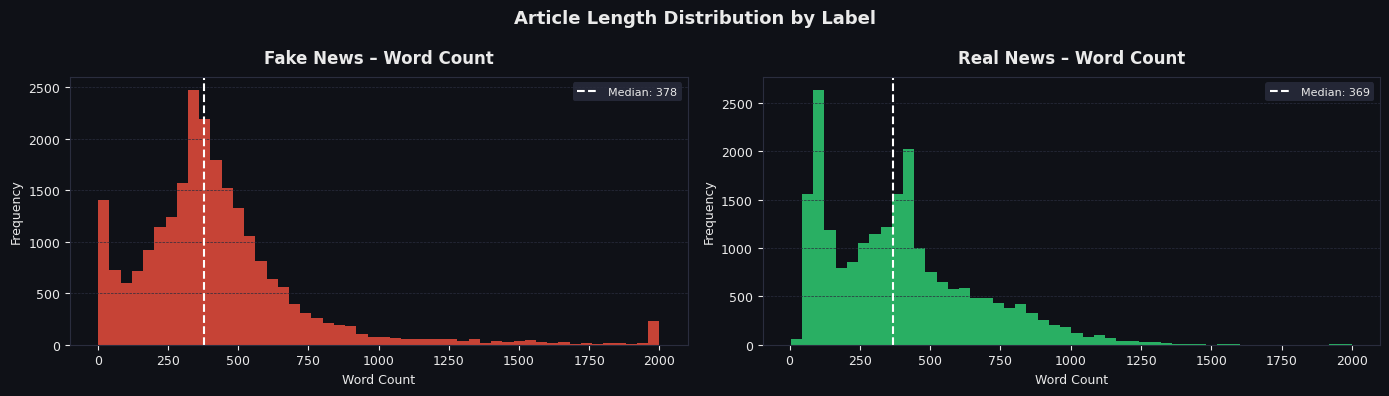


Word Count Statistics by Label:
              count   mean    std  min    25%    50%    75%     max
label_name                                                         
Fake        23481.0  437.9  408.6  2.0  254.0  378.0  521.0  8148.0
Real        21417.0  395.6  273.9  4.0  159.0  369.0  534.0  5181.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=BG)
fig.suptitle("Article Length Distribution by Label",
             color=TEXT_CLR, fontsize=13, fontweight="bold")

for ax, (lname, ldf) in zip(axes, df.groupby("label_name")):
    ax.set_facecolor(BG)
    ax.hist(ldf["word_count"].clip(upper=2000), bins=50,
            color=PALETTE[lname], edgecolor="none", alpha=0.85)
    ax.axvline(ldf["word_count"].median(), color="white",
               linestyle="--", linewidth=1.5,
               label=f"Median: {ldf['word_count'].median():.0f}")
    ax.legend(fontsize=8, labelcolor=TEXT_CLR, facecolor=GRID_CLR, edgecolor="none")
    style_ax(ax, f"{lname} News – Word Count", "Word Count", "Frequency")

plt.tight_layout()
plt.show()

# Summary stats
print("\nWord Count Statistics by Label:")
print(df.groupby("label_name")["word_count"].describe().round(1).to_string())


 3.3 Word Count Boxplot

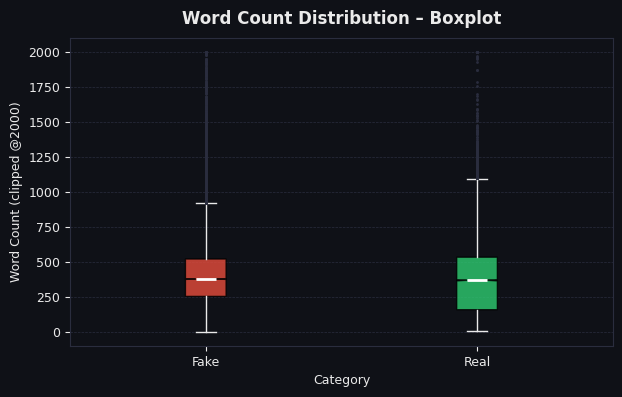

In [15]:
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
ax.set_facecolor(BG)
data_by_label = [df[df.label_name == l]["word_count"].clip(upper=2000).values
                 for l in ["Fake", "Real"]]
bp = ax.boxplot(data_by_label, labels=["Fake", "Real"],
                patch_artist=True, notch=True,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(color=TEXT_CLR),
                capprops=dict(color=TEXT_CLR),
                flierprops=dict(marker="o", markersize=2,
                                markerfacecolor=GRID_CLR, markeredgewidth=0))
for patch, clr in zip(bp["boxes"], [PALETTE["Fake"], PALETTE["Real"]]):
    patch.set_facecolor(clr); patch.set_alpha(0.8)
style_ax(ax, "Word Count Distribution – Boxplot",
         "Category", "Word Count (clipped @2000)")
plt.show()


 3.4 Top 20 Most Frequent Words

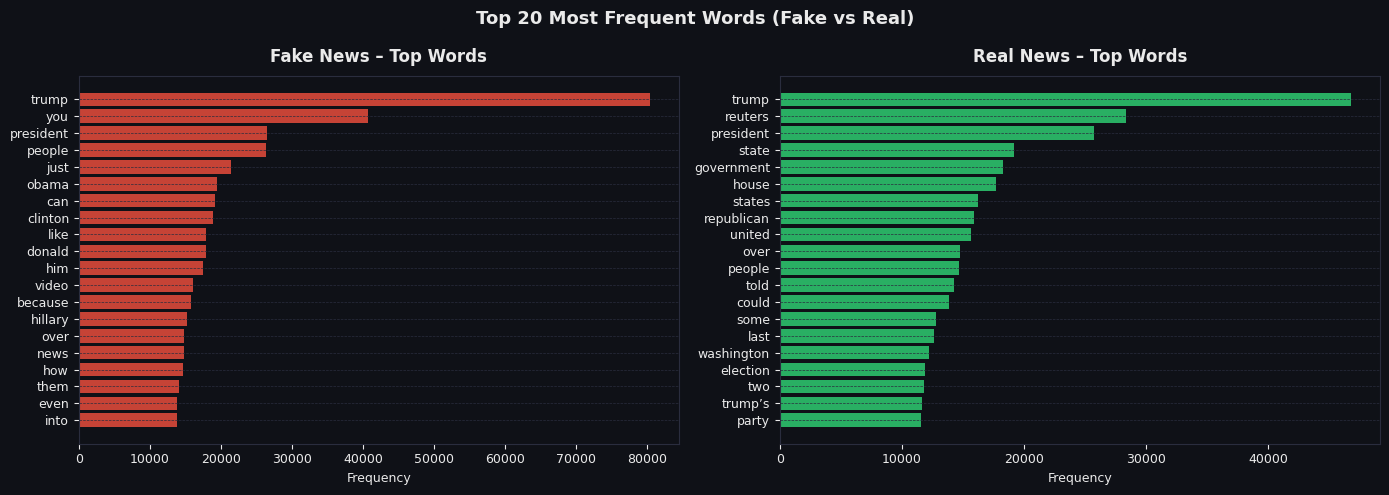

In [16]:
STOP = {
    "the","a","an","in","on","at","to","of","and","that","said","was","for",
    "by","with","are","from","this","will","have","been","its","has","not",
    "new","he","she","they","it","his","her","their","we","our","as","but",
    "or","which","had","i","is","be","who","all","more","than","were",
    "about","after","before","also","if","so","up","out","there","when",
    "would","one","what","s","t","re","ve","d","ll",
}

def top_words(text_series, n=20):
    tokens = (" ".join(text_series)
              .lower()
              .translate(str.maketrans("", "", string.punctuation))
              .split())
    tokens = [t for t in tokens if t not in STOP and len(t) > 2]
    return Counter(tokens).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle("Top 20 Most Frequent Words (Fake vs Real)",
             color=TEXT_CLR, fontsize=13, fontweight="bold")

for ax, lname in zip(axes, ["Fake", "Real"]):
    ax.set_facecolor(BG)
    words, freqs = zip(*top_words(df[df.label_name == lname]["text"]))
    y_pos = range(len(words))
    ax.barh(list(y_pos), list(freqs), color=PALETTE[lname],
            edgecolor="none", alpha=0.85)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(list(words), fontsize=9, color=TEXT_CLR)
    style_ax(ax, f"{lname} News – Top Words", "Frequency", "")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


 3.5 Word Clouds

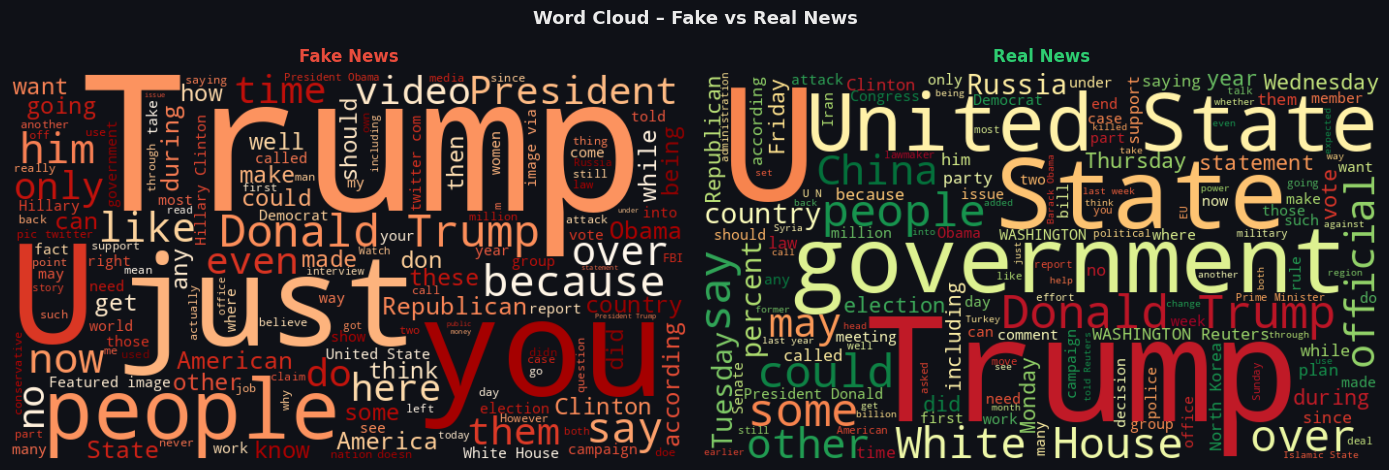

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle("Word Cloud – Fake vs Real News",
             color=TEXT_CLR, fontsize=13, fontweight="bold")

for ax, lname in zip(axes, ["Fake", "Real"]):
    subset_text = " ".join(
        df[df.label_name == lname]["text"].sample(
            min(5000, (df.label_name == lname).sum()), random_state=42))
    wc = WordCloud(
        width=700, height=400,
        background_color="#0F1117",
        colormap="RdYlGn" if lname == "Real" else "OrRd",
        max_words=150, stopwords=STOP,
    ).generate(subset_text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{lname} News", color=PALETTE[lname],
                 fontsize=12, fontweight="bold", pad=8)

plt.tight_layout()
plt.show()


3.6 Average Word Length Distribution

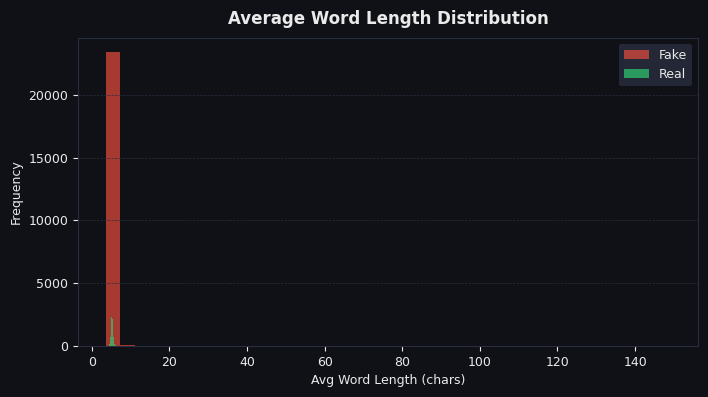

In [18]:
df["avg_word_len"] = df["text"].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0)

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
for lname in ["Fake", "Real"]:
    ax.hist(df[df.label_name == lname]["avg_word_len"],
            bins=40, color=PALETTE[lname], alpha=0.7,
            label=lname, edgecolor="none")
ax.legend(fontsize=9, labelcolor=TEXT_CLR, facecolor=GRID_CLR, edgecolor="none")
style_ax(ax, "Average Word Length Distribution",
         "Avg Word Length (chars)", "Frequency")
plt.show()


3.7 Feature Correlation Heatmap

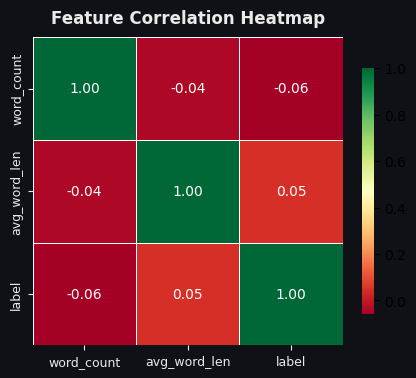

In [19]:
corr = df[["word_count", "avg_word_len", "label"]].corr()

fig, ax = plt.subplots(figsize=(5, 4), facecolor=BG)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax,
            linewidths=0.5, annot_kws={"size": 10, "color": "white"},
            cbar_kws={"shrink": 0.8})
ax.set_facecolor(BG)
ax.tick_params(colors=TEXT_CLR, labelsize=9)
ax.set_title("Feature Correlation Heatmap",
             color=TEXT_CLR, fontsize=12, fontweight="bold", pad=10)
plt.show()


Text Preprocessing

In [20]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)                # letters only
    text = re.sub(r"\s+", " ", text).strip()              # collapse spaces
    return text

print("Cleaning text …")
df["clean_text"] = df["text"].fillna("").apply(clean_text)
print(f" Done – {len(df):,} articles cleaned")
df[["text", "clean_text", "label_name"]].head(3)


Cleaning text …
 Done – 44,898 articles cleaned


,text,clean_text,label_name
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends out embarrassing new year s...,Fake
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...,Fake
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes an internet joke ...,Fake


 TF-IDF Vectorisation & Train/Test Split

In [21]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set : {len(X_train):,} samples")
print(f"Test  set : {len(X_test):,} samples")

tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),   # unigrams + bigrams
    sublinear_tf=True,    # log(1+tf)
    min_df=2,
)
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf  = tfidf.transform(X_test)

print(f"\nTF-IDF vocabulary size : {len(tfidf.vocabulary_):,}")
print(f"Feature matrix shape   : {X_train_tf.shape}")


Train set : 35,918 samples
Test  set : 8,980 samples

TF-IDF vocabulary size : 50,000
Feature matrix shape   : (35918, 50000)


 Logistic Regression Training

In [22]:
model = LogisticRegression(
    C=5.0,
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train_tf, y_train)
print(" Model training complete")


 Model training complete


 Model Evaluation

In [23]:
train_acc = accuracy_score(y_train, model.predict(X_train_tf))
test_acc  = accuracy_score(y_test,  model.predict(X_test_tf))
y_pred    = model.predict(X_test_tf)

print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing  Accuracy : {test_acc:.4f}")
print("\n" + "="*60)
print("Classification Report")
print("="*60)
print(classification_report(y_test, y_pred,
                             target_names=["Fake (0)", "Real (1)"]))


Training Accuracy : 0.9978
Testing  Accuracy : 0.9949

Classification Report
              precision    recall  f1-score   support

    Fake (0)       1.00      0.99      1.00      4696
    Real (1)       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980




 7.1 Train vs Test Score Bar Chart

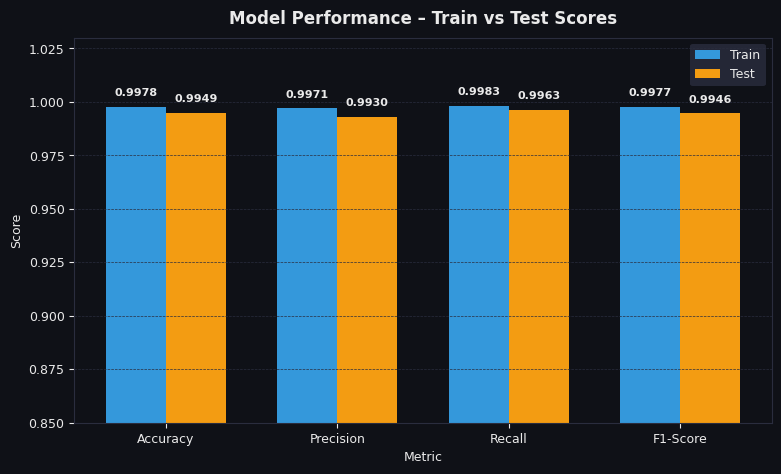

In [24]:
metrics = {
    "Accuracy" : (train_acc, test_acc),
    "Precision": (precision_score(y_train, model.predict(X_train_tf)),
                  precision_score(y_test, y_pred)),
    "Recall"   : (recall_score(y_train,  model.predict(X_train_tf)),
                  recall_score(y_test,  y_pred)),
    "F1-Score" : (f1_score(y_train,     model.predict(X_train_tf)),
                  f1_score(y_test,     y_pred)),
}

x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
b1 = ax.bar(x - w/2, [v[0] for v in metrics.values()], w,
            label="Train", color="#3498DB", edgecolor="none")
b2 = ax.bar(x + w/2, [v[1] for v in metrics.values()], w,
            label="Test",  color="#F39C12", edgecolor="none")
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f"{bar.get_height():.4f}",
                ha="center", va="bottom",
                color=TEXT_CLR, fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(list(metrics.keys()), color=TEXT_CLR)
ax.set_ylim(0.85, 1.03)
ax.legend(fontsize=9, labelcolor=TEXT_CLR, facecolor=GRID_CLR, edgecolor="none")
style_ax(ax, "Model Performance – Train vs Test Scores", "Metric", "Score")
plt.show()


 7.2 Confusion Matrix

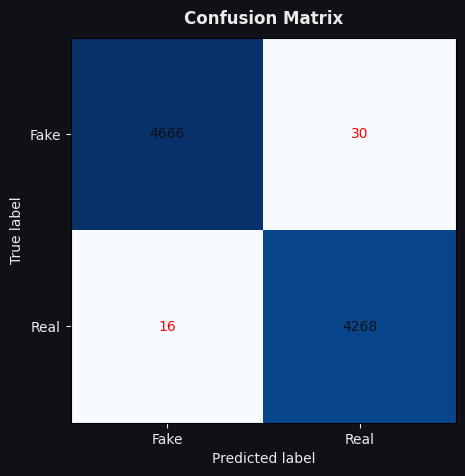

True Positives  (Real correctly identified) : 4,268
True Negatives  (Fake correctly identified) : 4,666
False Positives (Fake wrongly called Real)  : 30
False Negatives (Real wrongly called Fake)  : 16


In [26]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fake", "Real"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_facecolor(BG)
ax.tick_params(colors=TEXT_CLR)
ax.xaxis.label.set_color(TEXT_CLR)
ax.yaxis.label.set_color(TEXT_CLR)
ax.set_title("Confusion Matrix", color=TEXT_CLR,
             fontsize=12, fontweight="bold", pad=10)
for text in ax.texts:
    text.set_color("red" if int(text.get_text()) < cm.max()/2 else BG)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (Real correctly identified) : {tp:,}")
print(f"True Negatives  (Fake correctly identified) : {tn:,}")
print(f"False Positives (Fake wrongly called Real)  : {fp:,}")
print(f"False Negatives (Real wrongly called Fake)  : {fn:,}")


 7.3 ROC Curve

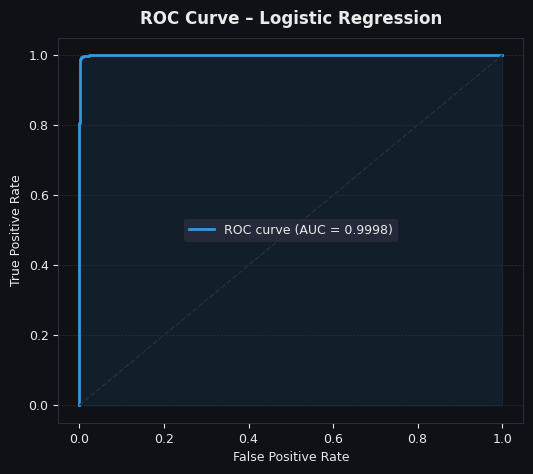

AUC Score: 0.9998


In [27]:
y_prob = model.predict_proba(X_test_tf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
ax.plot(fpr, tpr, color="#3498DB", lw=2,
        label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0,1],[0,1], color=GRID_CLR, linestyle="--", lw=1)
ax.fill_between(fpr, tpr, alpha=0.1, color="#3498DB")
ax.legend(fontsize=9, labelcolor=TEXT_CLR, facecolor=GRID_CLR, edgecolor="none")
style_ax(ax, "ROC Curve – Logistic Regression",
         "False Positive Rate", "True Positive Rate")
plt.show()
print(f"AUC Score: {roc_auc:.4f}")


 7.4 Top TF-IDF Features (Model Coefficients)

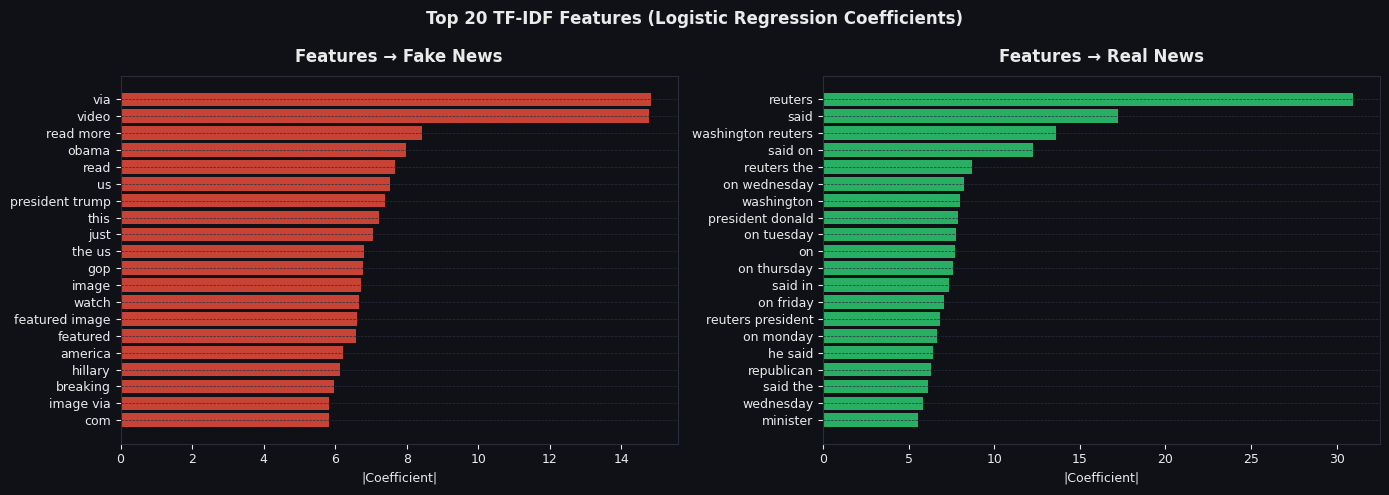

In [28]:
feature_names = np.array(tfidf.get_feature_names_out())
coef          = model.coef_[0]
top_fake_idx  = np.argsort(coef)[:20]
top_real_idx  = np.argsort(coef)[-20:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle("Top 20 TF-IDF Features (Logistic Regression Coefficients)",
             color=TEXT_CLR, fontsize=12, fontweight="bold")

for ax, idx, lname in zip(axes,
                           [top_fake_idx, top_real_idx],
                           ["Fake", "Real"]):
    ax.set_facecolor(BG)
    feats = feature_names[idx]
    vals  = np.abs(coef[idx])
    y_pos = range(len(feats))
    ax.barh(list(y_pos), list(vals), color=PALETTE[lname],
            edgecolor="none", alpha=0.85)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(list(feats), fontsize=9, color=TEXT_CLR)
    style_ax(ax, f"Features → {lname} News", "|Coefficient|", "")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


 Save Model Artifacts

In [29]:
os.makedirs("./model", exist_ok=True)
joblib.dump(model, "./model/logistic_regression.pkl")
joblib.dump(tfidf,  "./model/tfidf_vectorizer.pkl")
print(" Saved: model/logistic_regression.pkl")
print(" Saved: model/tfidf_vectorizer.pkl")


 Saved: model/logistic_regression.pkl
 Saved: model/tfidf_vectorizer.pkl


 Gradio Web Interface



In [32]:
import gradio as gr
import re

def clean_text_ui(text: str) -> str:
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def predict_news(text: str):
    if not text.strip():
        return " Please enter some news text.", "", ""
    cleaned   = clean_text_ui(text)
    vec       = tfidf.transform([cleaned])
    pred      = model.predict(vec)[0]
    proba     = model.predict_proba(vec)[0]
    fake_prob = round(proba[0] * 100, 2)
    real_prob = round(proba[1] * 100, 2)
    if pred == 1:
        label   = "✅  REAL NEWS"
        verdict = f"The model classifies this article as **REAL** with **{real_prob}% confidence**."
    else:
        label   = "🚨  FAKE NEWS"
        verdict = f"The model classifies this article as **FAKE** with **{fake_prob}% confidence**."
    bar = f"🟢 Real: {real_prob}%  |  🔴 Fake: {fake_prob}%"
    return label, verdict, bar

css = """
body { font-family: 'Segoe UI', sans-serif; }
#title { text-align: center; padding: 10px; }
"""

with gr.Blocks(
    title="Fake News Detection System",
    theme=gr.themes.Base(primary_hue="emerald", neutral_hue="slate"),
    css=css,
) as demo:

    gr.HTML("""
    <div id='title'>
        <h1>📰 Fake News Detection System</h1>
        <p style='color:#888; font-size:14px;'>
            Logistic Regression + TF-IDF &nbsp;|&nbsp;

        </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=3):
            inp = gr.Textbox(
                label="📝 Paste News Article Here",
                placeholder="Enter a news headline or article to verify …",
                lines=10, max_lines=20,
            )
            with gr.Row():
                submit_btn = gr.Button("🔍 Analyse", variant="primary", scale=3)
                clear_btn  = gr.Button("🗑 Clear",   variant="secondary", scale=1)

        with gr.Column(scale=2):
            gr.Markdown("### 📊 Prediction Result")
            out_label   = gr.Textbox(label="Verdict", interactive=False)
            out_explain = gr.Markdown()
            out_bar     = gr.Textbox(label="Confidence Breakdown", interactive=False)
            gr.Markdown("---")
            gr.Markdown("#### 📈 Model Performance Summary")
            gr.DataFrame(
                pd.DataFrame({
                    "Metric" : ["Accuracy","Precision","Recall","F1-Score"],
                    "Train"  : [f"{train_acc:.4f}",
                                f"{precision_score(y_train, model.predict(X_train_tf)):.4f}",
                                f"{recall_score(y_train, model.predict(X_train_tf)):.4f}",
                                f"{f1_score(y_train, model.predict(X_train_tf)):.4f}"],
                    "Test"   : [f"{test_acc:.4f}",
                                f"{precision_score(y_test, y_pred):.4f}",
                                f"{recall_score(y_test, y_pred):.4f}",
                                f"{f1_score(y_test, y_pred):.4f}"],
                }),
                interactive=False,
            )

    with gr.Accordion(" Example Articles – Click to Load", open=False):
        gr.Examples(
            examples=[
                ["Scientists from Harvard Medical School published research showing regular exercise "
                 "reduces cardiovascular disease risk by 35%, according to a study of 12,000 participants."],
                ["SHOCKING: Government secretly puts mind-control chemicals in tap water – leaked "
                 "documents expose the globalist elite deep state agenda they don't want you to know! "
                 "Share before it gets banned and censored!"],
                ["The Federal Reserve raised interest rates by 25 basis points as widely expected, "
                 "citing continued inflation above the 2% target. Officials noted labor conditions remain resilient."],
                ["EXPLOSIVE: Mainstream media hiding bombshell truth about election fraud – insider "
                 "whistleblower exposes rigged system. Wake up – the puppet masters are running a cover-up!"],
            ],
            inputs=inp,
        )



    submit_btn.click(predict_news, inputs=inp, outputs=[out_label, out_explain, out_bar])
    clear_btn .click(lambda: ("","",""), outputs=[out_label, out_explain, out_bar])
    inp.submit(predict_news, inputs=inp, outputs=[out_label, out_explain, out_bar])

demo.launch(share=True, server_port=7861)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c87d2ce53aa1b3cea4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
